Eigenfaces and Face Recognition

Importing the necessary libraries. Note that the actual logic and algorithms are implemented purely on numpy. The imported "ai211" is a custom python file to store necessary functions and classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

from ai211 import svd, inverse, scale_data, SimpleANN, norm2

Define a function that turns each row into a 2 dimensional matrix that can be viewed as an image.

In [2]:
def plot_faces(X, dim=(10, 10)):
    m = int(dim[0])
    n = int(dim[1])
    fig, axes = plt.subplots(m, n, figsize=(10, 10))
    for idx, ax in enumerate(axes.flat):
        ax.imshow(X[idx].reshape(32, 32).T, cmap='gray')
        ax.axis('off')

Load the faces into a matrix. Here, the mean of the faces is subtracted so that the data only contains the important variances that define the faces. The average or mean face is also visualized.

In [3]:
X = loadmat('faces.mat')['X']
X_mean = X.mean(axis=0)
X_no_mean = X - X_mean

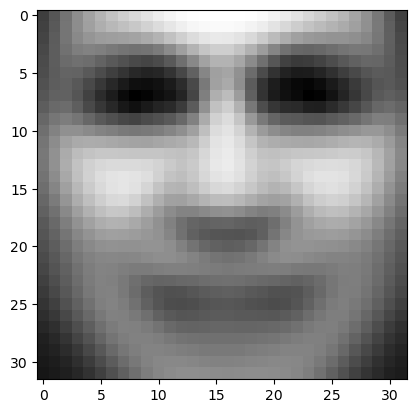

In [4]:
plt.imshow(X_mean.reshape(32, 32).T, cmap='gray');

For the next line, it is shown here the decomposition of the dataset. The actual implementation of the function can be found in the ai211 python file. Also, the decomposed matrices are saved to a .npz file since the decomposition took some time.

In [ ]:
# Takes some time to run. Saved the arrays to 'USVt_arr.npz' instead.
U, S, Vt = svd(X_no_mean)

In [ ]:
np.savez('USVt_arr', U=U, S=S, Vt=Vt)

When the kernel of this notebook is restarted, the arrays are saved on the external file.

In [5]:
decomposed_arr = np.load('USVt_arr.npz')
U = decomposed_arr['U']
S = decomposed_arr['S']
Vt = decomposed_arr['Vt']

The matrix Vt containing the eigenfaces are plotted. Shown here are the first 36 eigenfaces. These show the important features that make up the faces.

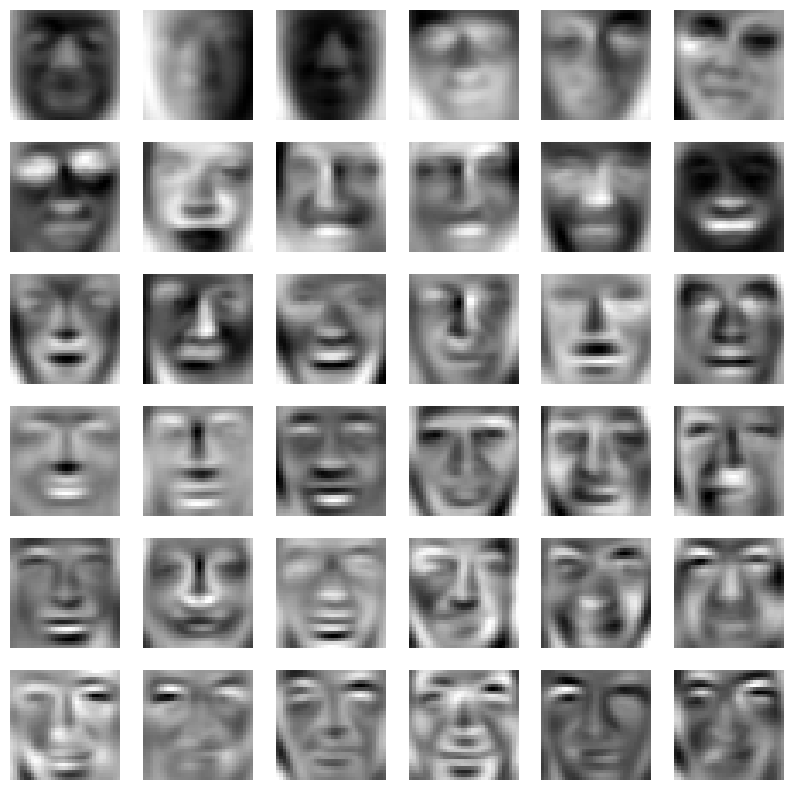

In [6]:
plot_faces(-Vt, (6, 6))

The next two plots also show eigenfaces but corresponds to a low singular value. The plots are observed to look like noise and contains little information.

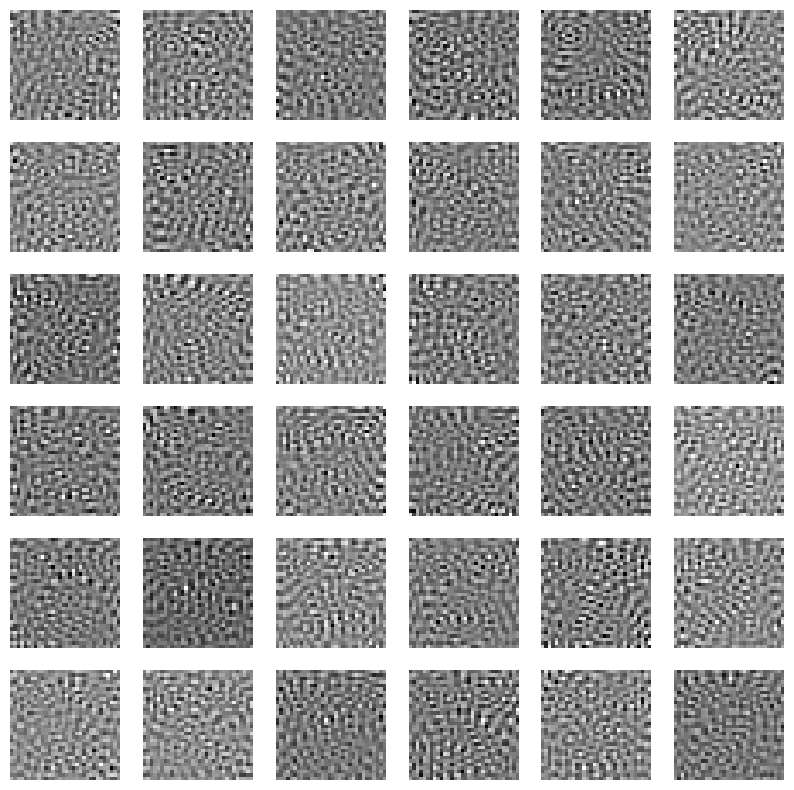

In [7]:
plot_faces(-Vt[400:], (6, 6))

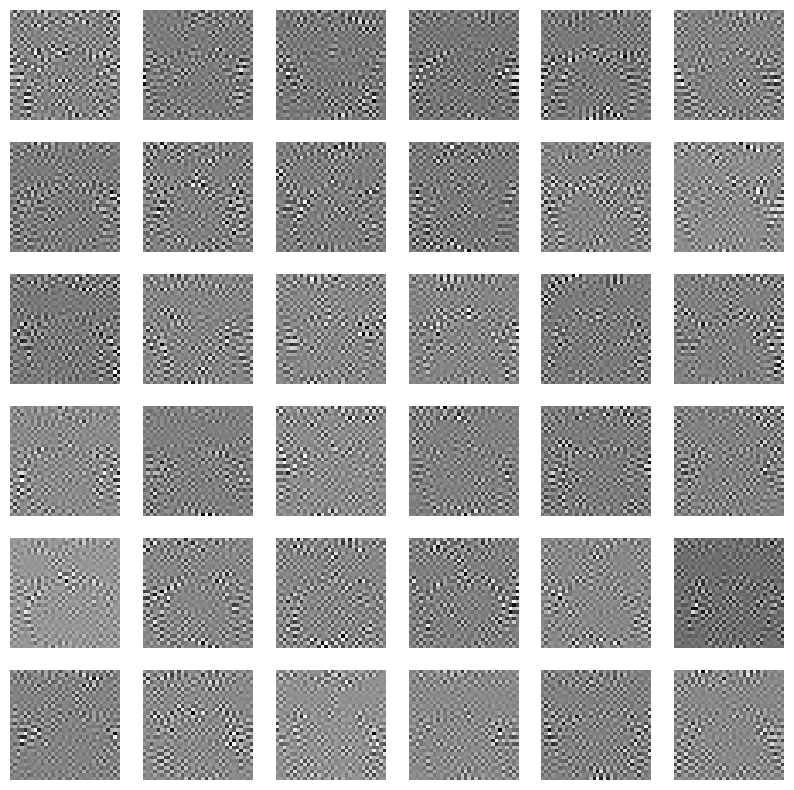

In [8]:
plot_faces(-Vt[900:], (6, 6))

Shown is the plot of reconstruction error vs eigenfaces. The reconstruction error at the early eigenfaces greatly decreases however the decrease start to decrease.

In [9]:
n = 100
errors = []
for k in range(0, n):
    U_k = U[:, :k]
    S_k = S[:k, :k]
    Vt_k = Vt[:k, :]
    X_reconstructed = U_k @ S_k @ Vt_k + X_mean
    error = X - X_reconstructed
    error = np.mean(np.linalg.norm(error, axis=1), axis=0)
    errors.append(error)

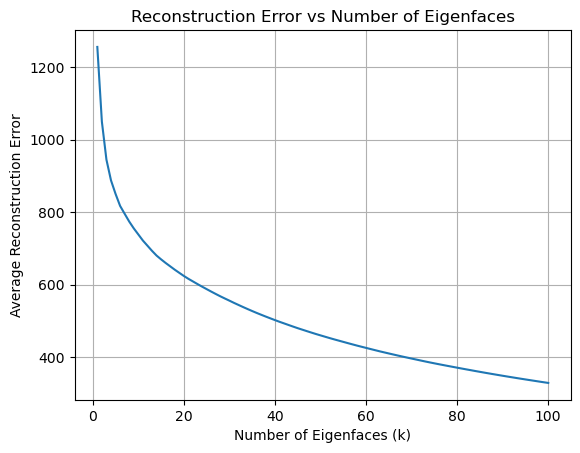

In [10]:
plt.plot(range(1, n+1), errors)
plt.xlabel('Number of Eigenfaces (k)')
plt.ylabel('Average Reconstruction Error')
plt.title('Reconstruction Error vs Number of Eigenfaces')
plt.grid()

For the first 100 eigenfaces, the reconstructed pictures does not look that bad and very similar to the first with some few information losses. This proves that only the eigenfaces corresponding to high singular values carry the most information while the remaining contains too much randomness or noise.

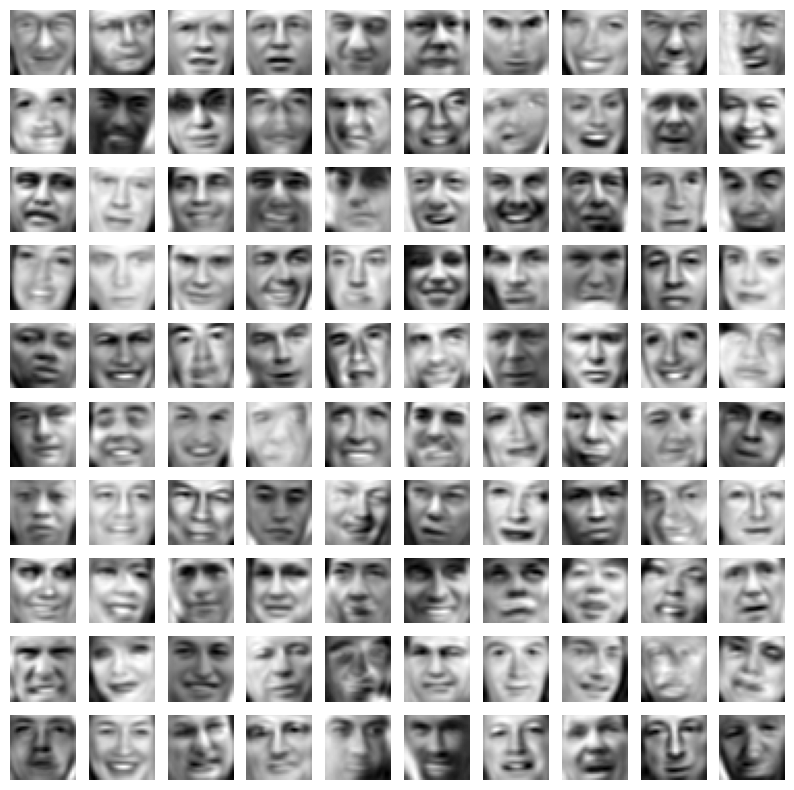

In [11]:
U_100 = U[:, :100]
S_100 = S[:100, :100]
Vt_100 = Vt[:100, :]
X_reconstructed = U_100 @ S_100 @ Vt_100 + X_mean
plot_faces(X_reconstructed, (10, 10))

Nonlinear vs Linearized Least Squares Regression

Defining the experimental or measured values. Also the necessary functions are hardcoded for this case.

In [12]:
C = np.array([2.5, 5., 10., 15., 20.])
v0 = np.array([0.024, 0.036, 0.053, 0.06, 0.064])

In [13]:
def v0_model(C, Vmax, Km):
    return Vmax / (1 + Km/C)

def residuals(theta, C, v0):
    return v0_model(C, theta[0], theta[1]) - v0

def J_r(theta, C):
    Vmax, Km = theta
    J = np.zeros((len(C), len(theta)))
    J[:, 0] = C / (C + Km)
    J[:, 1] = -(C * Vmax) / (C + Km) ** 2
    return J

Initializing the parameters and then performing Gauss-Newton to solve for the parameters.

In [14]:
theta = np.random.randint(size=(2,), low=1, high=2)
# Iteration
for _ in range(100):
    r = residuals(theta, C, v0)
    J = J_r(theta, C)
    H = J.T @ J
    theta = theta - inverse(H) @ J.T @ r

print(f'Vmax = {theta[0]:.6f}; Km = {theta[1]:.6f}')

Vmax = 0.085857; Km = 6.561894


Plot for experimental data vs predicted data is shown.

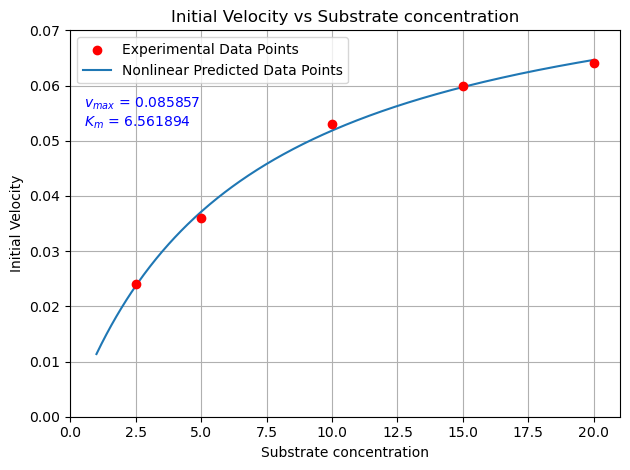

In [15]:
vmax_text = f'$v_{{max}}$ = {theta[0]:.6f}'
km_text = f'$K_m$ = {theta[1]:.6f}'

C_fit = np.linspace(1, 20, 400)
nl_v0_fit = v0_model(C_fit, theta[0], theta[1])

plt.scatter(C, v0, color='r', label='Experimental Data Points', zorder=3)
plt.plot(C_fit, nl_v0_fit, label='Nonlinear Predicted Data Points', zorder=2)
plt.grid(True)
plt.xlabel('Substrate concentration')
plt.ylabel('Initial Velocity')
plt.title('Initial Velocity vs Substrate concentration');
plt.legend()
plt.xlim(0, 21)
plt.ylim(0, 0.07)
plt.xticks(np.arange(0, 21, 2.5))
plt.yticks(np.arange(0, 0.071, 0.01))
plt.text(0.025, 0.8, vmax_text, transform=plt.gca().transAxes, fontsize=10, 
         color='blue')
plt.text(0.025, 0.75, km_text, transform=plt.gca().transAxes, fontsize=10, 
         color='blue')
plt.tight_layout()

A direct solution for solving linear models.

In [16]:
def solve_theta(cols, y):
    A = np.column_stack(cols)
    U, S, Vt = svd(A)
    S_pinv = inverse(S.T @ S) @ S.T
    theta = Vt.T @ S_pinv @ U.T @ y

    return theta

Solving the 3 linear models.

In [17]:
# Lineweaver
lineweaver_y = 1 / v0
lineweaver_col_0 = np.ones(5)
lineweaver_col_1 = np.array([1/c for c in C])

lineweaver_theta = solve_theta(
    (lineweaver_col_0, lineweaver_col_1), 
    lineweaver_y
)

lineweaver_vmax = 1 / lineweaver_theta[0]
lineweaver_Km = lineweaver_theta[1] * lineweaver_vmax
print(f'Lineaweaver vmax = {lineweaver_vmax:.6f}')
print(f'Lineaweaver Km = {lineweaver_Km:.6f}')

Convergence
Lineaweaver vmax = 0.084743
Lineaweaver Km = 6.392313


In [18]:
# Dixon
dixon_y = C / v0
dixon_col_0 = np.ones(5)
dixon_col_1 = C

dixon_theta = solve_theta(
    (dixon_col_0, dixon_col_1),
    dixon_y
)

dixon_vmax = 1 / dixon_theta[1]
dixon_Km = dixon_theta[0] * dixon_vmax
print(f'Dixon vmax = {dixon_vmax:.6f}')
print(f'Dixon Km = {dixon_Km:.6f}')

Convergence
Dixon vmax = 0.085339
Dixon Km = 6.469373


In [19]:
# Eadie
eadie_y = v0
eadie_col_0 = np.ones(5)
eadie_col_1 = -v0 / C

eadie_theta = solve_theta(
    (eadie_col_0, eadie_col_1),
    eadie_y
)

eadie_vmax, eadie_Km = eadie_theta
print(f'Eadie vmax = {eadie_vmax:.6f}')
print(f'Eadie Km = {eadie_Km:.6f}')

Convergence
Eadie vmax = 0.085581
Eadie Km = 6.515470


Showing the errors when compared to the gauss newton method.

In [20]:
print('Errors compared to vmax')
for i in [theta[0], lineweaver_vmax, dixon_vmax, eadie_vmax]:
    print(f'{abs((theta[0] - i)/theta[0])*100:.2f}')
print('')

print('Errors compared to Km')
for i in [theta[1], lineweaver_Km, dixon_Km, eadie_Km]:
    print(f'{abs((theta[1] - i)/theta[1])*100:.2f}')
print('')

Errors compared to vmax
0.00
1.30
0.60
0.32

Errors compared to Km
0.00
2.58
1.41
0.71



Showing the plots of the 4 models (1 NL and 3 Linear). Viusually, very little error can be observed.

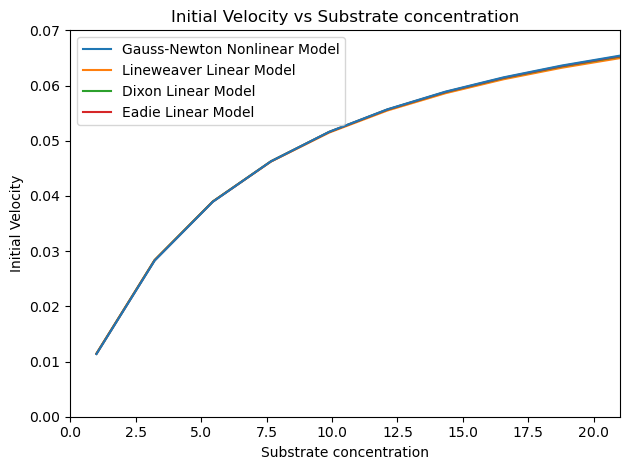

In [21]:
C_fit_2 = np.linspace(1, 21, 10)
nl_v0_fit = v0_model(C_fit_2, theta[0], theta[1])
lineweaver_v0_fit = v0_model(C_fit_2, lineweaver_vmax, lineweaver_Km)
dixon_v0_fit = v0_model(C_fit_2, dixon_vmax, dixon_Km)
eadie_v0_fit = v0_model(C_fit_2, eadie_vmax, eadie_Km)

plt.plot(C_fit_2, nl_v0_fit, label='Gauss-Newton Nonlinear Model', zorder=4)
plt.plot(C_fit_2, lineweaver_v0_fit, label='Lineweaver Linear Model')
plt.plot(C_fit_2, dixon_v0_fit, label='Dixon Linear Model')
plt.plot(C_fit_2, eadie_v0_fit, label='Eadie Linear Model')
plt.xlabel('Substrate concentration')
plt.ylabel('Initial Velocity')
plt.title('Initial Velocity vs Substrate concentration');
plt.legend()
plt.xlim(0, 21)
plt.ylim(0, 0.07)
plt.xticks(np.arange(0, 21, 2.5))
plt.yticks(np.arange(0, 0.071, 0.01))
plt.tight_layout()

MNIST Handwritten Digit Classification Using ANN

Loading the features X and label y. The 10's in the y are reencoded to 0 for convenience.

In [22]:
data = loadmat('mnist.mat')
X = data['X']
y = data['y']
y = np.where(y==10, 0, y)

The class SimpleANN and methods can be seen on ai211. The dataset is initially trained using suggested parameters.

In [23]:
model = SimpleANN(
    input_layer_size=400,
    hidden_layer_size=25,
    num_labels=10,
    alpha=0.0005,
    n_iters=100
)
model.train(X, y)

Defining some functions.

In [25]:
def show_incorrect_preds(X, y, model):
    predictions = model.predict(X)
    return np.argwhere(np.where(predictions!=y.flatten(), 1, 0)).reshape(-1)

def show_classifcation_error(X, y, model):
    predictions = model.predict(X)
    error_count = np.argwhere(
        np.where(predictions!=y.flatten(), 1, 0)
    ).shape[0]
    return error_count / X.shape[0] * 100

def show_predict(X, pic_pos, model):
    predictions = model.predict(X)
    plt.imshow(-X[pic_pos].reshape(20, 20).T, cmap='gray')
    plt.show()
    print(f'Predicted value: {predictions[pic_pos]}')
    print(f'Actual value: {y.flatten()[pic_pos]}')


In [26]:
def plot_loss_epoch_per_alpha(alphas=[0.00005], n_iter=100):
    X_y_pairs = []
    clf_errors = []
    for alpha in alphas:
        model = SimpleANN(
            input_layer_size=400,
            hidden_layer_size=25,
            num_labels=10,
            alpha=alpha,
            n_iters=n_iter
        )
        model.train(X, y)
        X_alpha = np.arange(model.epochs)
        y_alpha = model.losses
        X_y_pairs.append((X_alpha, y_alpha))
        clf_errors.append(show_classifcation_error(X, y, model))

    for i in range(len(alphas)):
        plt.title('Loss vs Number of Epochs')
        plt.plot(
            X_y_pairs[i][0], 
            X_y_pairs[i][1], 
            label=rf'$\alpha$={alphas[i]}, error={clf_errors[i]:.2f}%'
        )
    plt.title('Loss vs Number of Epochs')
    plt.xlabel('Number of Epochs')
    plt.ylabel('Loss')
    if np.min(X_y_pairs[-1][1]) < 1.15:
        plt.ylim(-.6, 1.5)
    plt.legend(loc='lower left')
    plt.tight_layout()
    plt.grid(True)

As seen, model predicts poorly. Classification error can be seen on next plots.

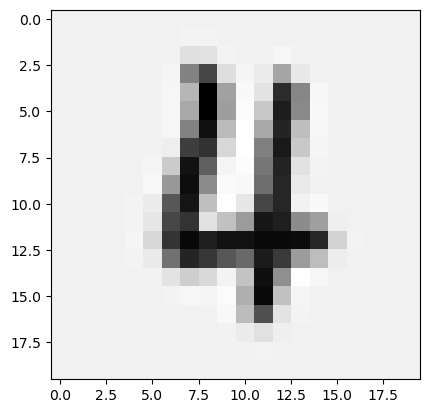

Predicted value: 0
Actual value: 4


In [27]:
show_predict(X, 2324, model)

Plotting the loss vs epoch for the initial alpha and 100 iterations (the first model that was trained which predicted poorly). Model looked like it is decreasing linearly however it is unknown to us if this is a good decrease of loss. Let us try to compare with other alpha or learning rate and also on a higher number of iterations. However, note that it yields a very high classification error. This meant that out of the 5000 images, it was only able to correctly predict around 600 images.

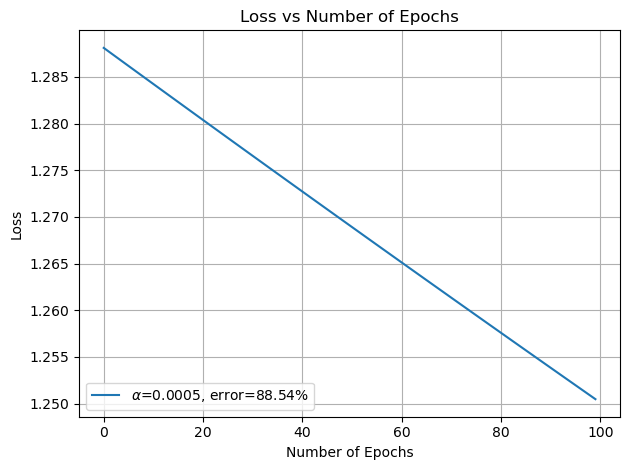

In [28]:
plot_loss_epoch_per_alpha(alphas=[0.0005], n_iter=100)

Here, it is observed that the loss decrease for the very first model was really negligible. For the other trained models at a higher learning rate, the decrease in loss is much more noticeable and yields a much lower classification error. However, the risk of overfitting could be encountered, but that is not the point for now.

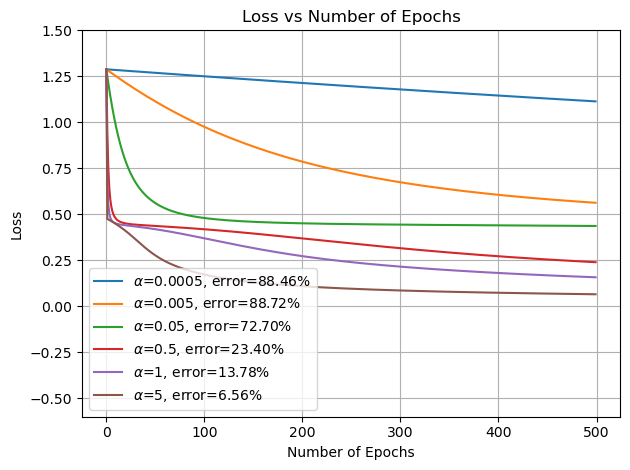

In [29]:
alphas = [0.0005, 0.005, 0.05, 0.5, 1, 5]
plot_loss_epoch_per_alpha(alphas, 500)

Using the model with a higher alpha and higher iterations, we can see that it was now able to predict the image that was icorrectly predicted by our initial model.

In [30]:
model = SimpleANN(
    input_layer_size=400,
    hidden_layer_size=25,
    num_labels=10,
    alpha=5,
    n_iters=500
)
model.train(X, y)

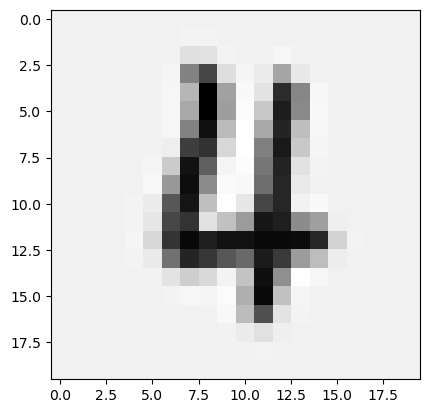

Predicted value: 4
Actual value: 4


In [31]:
show_predict(X, 2324, model)

Hybrid Optimization

Hardcoding the Beale function and its gradient.

In [32]:
def obj_func(X):
    x1, x2 = X[0], X[1]
    z = (1.5 - x1 + x1 * x2)**2 + \
        (2.25 - x1 + x1 * x2**2)**2 + \
        (2.625 - x1 + x1 * x2**3)**2
    return z


def obj_func_grad(X):
    x1, x2 = X[0], X[1]
    df_dx1 = 2 * (1.5 - x1 + x1 * x2) * (-1 + x2) + \
             2 * (2.25 - x1 + x1 * x2**2) * (-1 + x2**2) + \
             2 * (2.625 - x1 + x1 * x2**3) * (-1 + x2**3)
    df_dx2 = 2 * (1.5 - x1 + x1 * x2) * x1 + \
             4 * (2.25 - x1 + x1 * x2**2) * x1 * x2 + \
             6 * (2.625 - x1 + x1 * x2**3) * x1 * x2**2
    return np.array([df_dx1, df_dx2])

Defining BFGS with backtrack search and BFGS with trust region method.

In [33]:
def line_search_armijo(X, p, obj_func, obj_func_grad, 
                       alpha=1, 
                       tau=0.7, 
                       c=1e-4):
    m = obj_func_grad(X).T @ p
    while obj_func(X) - obj_func(X + alpha * p) < - alpha*c*m:
        alpha *= tau
    return alpha


def bfgs_w_backtrack(X_0, obj_func, obj_func_grad, 
                     max_iter=500, 
                     tol=1e-5, 
                     alpha=1, 
                     tau=0.7, 
                     c=1e-4):
    X_0 = X_0.copy()
    B_0 = np.eye(X_0.shape[0])
    gradient_0 = obj_func_grad(X_0)
    steps = [X_0.copy()]
    for i in range(max_iter):
        p = -B_0 @ gradient_0
        alpha = line_search_armijo(X_0, p, obj_func, obj_func_grad, alpha, 
                                   tau, c)
        X_1 = X_0 + alpha * p
        if np.allclose(X_0, X_1, tol):
            break
        gradient_1 = obj_func_grad(X_1)
        s_0 = X_1 - X_0
        y_0 = gradient_1 - gradient_0
        B_1 = B_0 \
            + (y_0 @ y_0.T)/(y_0.T @ s_0) \
            - (B_0 @ s_0 @ s_0.T @ B_0)/(s_0.T @ B_0 @ s_0)
        X_0 = X_1
        B_0 = B_1
        gradient_0 = gradient_1
        steps.append(X_0.copy())
    
    return X_0, obj_func(X_0), steps

In [34]:
def trust_region(p, delta):
    norm2_p = norm2(p)
    if norm2_p <= delta:
        return p
    else:
        return p * delta / norm2_p
    

def bfgs_w_trust_region(X_0, obj_func, obj_func_grad, 
                        max_iter=500, 
                        tol=1e-5,
                        delta_max=.01, 
                        eta=1e-2):
    n = len(X_0)
    B_0 = np.eye(n)
    X_0 = np.array(X_0).astype(float)
    delta = delta_max
    steps = [X_0.copy()]
    for i in range(max_iter):
        gradient_0 = obj_func_grad(X_0)
        p = -B_0 @ gradient_0
        p = trust_region(p, delta)

        rho = (obj_func(X_0) - obj_func(X_0 + p)) / (-gradient_0.T @ p - 0.5 * p.T @ B_0 @ p)

        if rho < 0.25:
            delta *= 0.25 
        elif rho > 0.75 and norm2(p) == delta:
            delta = min(2 * delta, delta_max)

        if rho > eta:
            X_1 = X_0 + p
            if np.allclose(X_0, X_1, tol):
                break
            gradient_1 = obj_func_grad(X_1)
            s_0 = X_1 - X_0
            y_0 = gradient_1 - gradient_0
            B_1 = B_0 \
                + (y_0 @ y_0.T)/(y_0.T @ s_0) \
                - (B_0 @ s_0 @ s_0.T @ B_0)/(s_0.T @ B_0 @ s_0)
            X_0 = X_1
            B_0 = B_1
            gradient_0 = gradient_1
            steps.append(X_0.copy())

    return X_0, obj_func(X_0), steps

Due to the issue that the algorithms get stuck at a local minima, a multirandom initialization method is implemented. The one yielding the best results is then selected.

In [35]:
def multi_start_bfgs_w_backtrack(starting_points, obj_func, obj_func_grad, 
                                max_iter=500, 
                                tol=1e-5, 
                                alpha=1, 
                                tau=0.7, 
                                c=1e-4):
    best_sol = None
    best_val = np.inf
    steps_for_best = []
    for X_0 in starting_points:
        result, func_val, steps = bfgs_w_backtrack(
            X_0, 
            obj_func, 
            obj_func_grad, 
            max_iter,
            tol,
            alpha,
            tau,
            c
        )
        if func_val < best_val:
            best_sol = result
            best_val = func_val
            steps_for_best = steps
    return best_sol, best_val, steps_for_best


def multi_start_bfgs_w_trust_region(starting_points, obj_func, obj_func_grad, 
                                    max_iter=500, 
                                    tol=1e-5, 
                                    delta_max=.01, 
                                    eta=1e-2):
    best_sol = None
    best_val = np.inf
    steps_for_best = []
    for X_0 in starting_points:
        result, func_val, steps = bfgs_w_trust_region(
            X_0, 
            obj_func, 
            obj_func_grad, 
            max_iter,
            tol,
            delta_max,
            eta
        )
        if func_val < best_val:
            best_sol = result
            best_val = func_val
            steps_for_best = steps
    return best_sol, best_val, steps_for_best

Function to visualize the trajectory of descent.

In [36]:
def plot_descent_path(results, func_val, steps, algo_name):
    steps = np.array(steps)

    x = np.linspace(-4.5, 4.5, 400)
    y = np.linspace(-4.5, 4.5, 400)
    x, y = np.meshgrid(x, y)
    z = obj_func([x, y])

    plt.figure(figsize=(10, 8))
    plt.contour(x, y, z, levels=np.logspace(-1, 5, 35), cmap='viridis')
    plt.plot(steps[:, 0], steps[:, 1], 'g-', markersize=5, linewidth=1.5, label='Path of Descent')
    plt.scatter(
        steps[-1, 0], 
        steps[-1, 1], 
        color='red', 
        s=100, 
        label=f'Optimum, (x={results[0][0]:.2f}, y={results[1][0]:.2f}, f(x, y)={func_val[0]:.2f}), n_iter={len(steps)}'
    )
    plt.colorbar(label='Function Value')
    plt.title(f'Contour Plot of Beale Function with Optimization Path using {algo_name}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

Of course the answer to life, the universe, and everything, is used as a seed.

In [37]:
np.random.seed(42)
starting_points = [np.random.uniform(-4.5, 4.5, (2, 1)) for _ in range(50)]

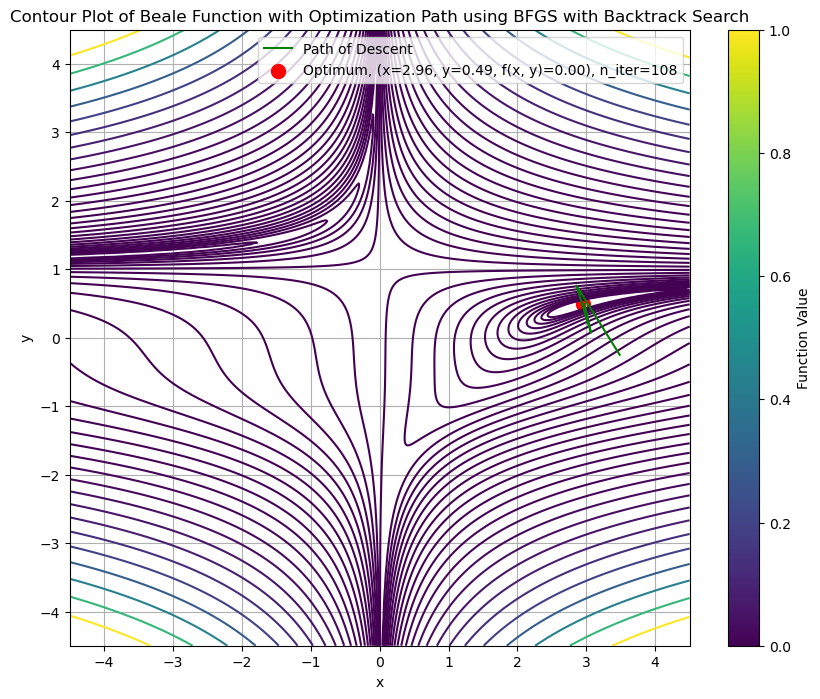

In [38]:
plot_descent_path(
    *multi_start_bfgs_w_backtrack(starting_points, obj_func, obj_func_grad), 
    'BFGS with Backtrack Search'
)

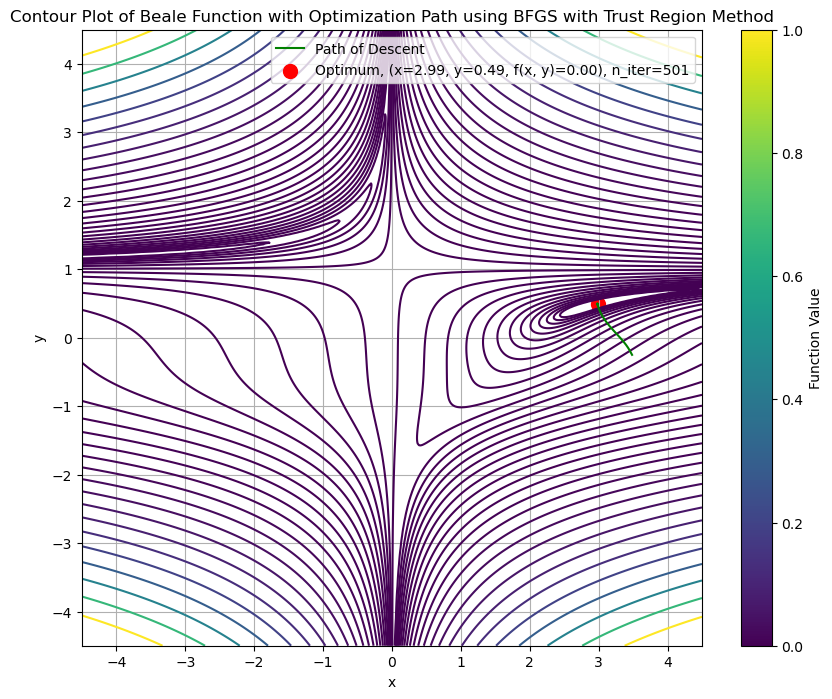

In [39]:
plot_descent_path(
    *multi_start_bfgs_w_trust_region(starting_points, obj_func, obj_func_grad), 
    'BFGS with Trust Region Method'
)